عدد الصفوف: 59
الأعمدة: ['text', 'label']

توزيع الفئات:
positive    24
negative    22
neutral     13
Name: label, dtype: int64


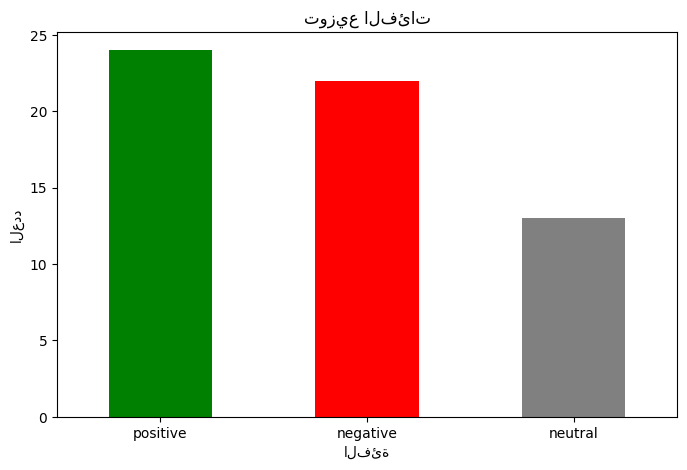

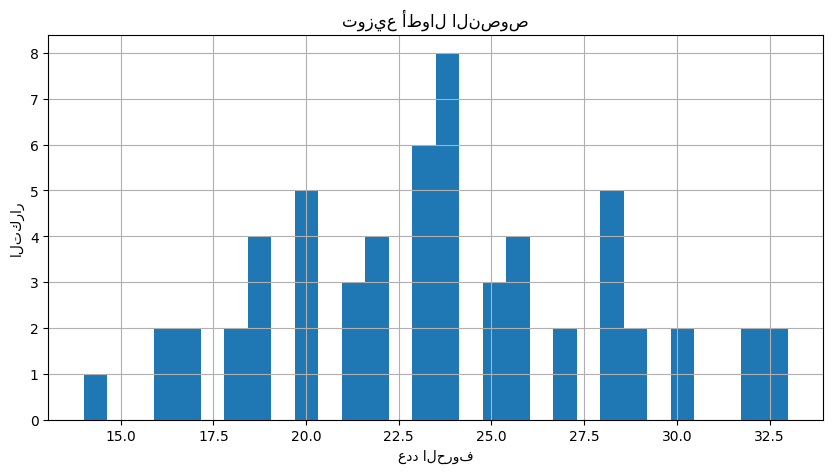


=== positive ===
  - هذا المنتج رائع جدا وأنصح به بشدة
  - الخدمة ممتازة وسريعة في الرد
  - أفضل عملية شراء قمت بها في حياتي

=== negative ===
  - تجربة سيئة للغاية ولن أكررها أبدا
  - المنتج سيء جدا ولا يستحق السعر
  - تأخر التوصيل ولم يستجب البائع

=== neutral ===
  - جودة عادية لا شيء مميز
  - سعر مناسب وجودة مقبولة
  - لا بأس به لكن ليس الأفضل
قبل: هذا المنتج رائع جدا وأنصح به بشدة
بعد: المنتج رايع جدا وانصح بشده
--------------------------------------------------
قبل: تجربة سيئة للغاية ولن أكررها أبدا
بعد: تجربه سييه للغايه ولن اكررها ابدا
--------------------------------------------------
قبل: الخدمة ممتازة وسريعة في الرد
بعد: الخدمه ممتازه وسريعه الرد
--------------------------------------------------
قبل: المنتج سيء جدا ولا يستحق السعر
بعد: المنتج سيء جدا يستحق السعر
--------------------------------------------------
قبل: جودة عادية لا شيء مميز
بعد: جوده عاديه شيء مميز
--------------------------------------------------


In [1]:
# Cell 1
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# إضافة src إلى المسار
PROJECT_ROOT = os.path.abspath("..")
sys.path.insert(0, os.path.join(PROJECT_ROOT, "src"))

from preprocessing import clean_text

# Cell 2 - تحميل البيانات
df = pd.read_csv(os.path.join(PROJECT_ROOT, "data", "raw", "dataset.csv"),
                 encoding='utf-8-sig')
df.head()

# Cell 3 - معلومات عامة
print(f"عدد الصفوف: {len(df)}")
print(f"الأعمدة: {list(df.columns)}")
print(f"\nتوزيع الفئات:")
print(df['label'].value_counts())

# Cell 4 - رسم توزيع الفئات
plt.figure(figsize=(8, 5))
df['label'].value_counts().plot(kind='bar', color=['green', 'red', 'gray'])
plt.title('توزيع الفئات')
plt.xlabel('الفئة')
plt.ylabel('العدد')
plt.xticks(rotation=0)
plt.show()

# Cell 5 - طول النصوص
df['text_length'] = df['text'].astype(str).apply(len)
df['text_length'].hist(bins=30, figsize=(10, 5))
plt.title('توزيع أطوال النصوص')
plt.xlabel('عدد الحروف')
plt.ylabel('التكرار')
plt.show()

# Cell 6 - عرض أمثلة
for label in df['label'].unique():
    print(f"\n=== {label} ===")
    samples = df[df['label'] == label]['text'].head(3).tolist()
    for s in samples:
        print(f"  - {s}")

# Cell 7 - اختبار التنظيف
sample_texts = df['text'].head(5).tolist()
for text in sample_texts:
    print(f"قبل: {text}")
    print(f"بعد: {clean_text(text)}")
    print("-" * 50)